<a href="https://colab.research.google.com/github/suryapratapkhuntia/Machine-Learning-End_to_end_project/blob/main/Credit_card_fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [139]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [140]:
df=pd.read_csv("/content/archive (28).zip")
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
117116,74545.0,1.126298,0.009887,1.157826,1.431000,-0.965565,-0.484414,-0.359836,-0.023159,0.704762,...,0.122258,0.583130,-0.113731,0.765168,0.616463,-0.238588,0.060758,0.036162,20.46,0
118130,74959.0,1.220089,0.576802,-0.365253,1.121952,0.208446,-0.692656,0.156710,-0.050598,-0.250822,...,-0.027342,-0.064184,-0.167556,-0.123118,0.690736,-0.322837,0.024724,0.036734,1.00,0
136965,81955.0,-1.288323,-0.740430,1.925546,3.415951,-1.619969,1.817141,-1.339293,-2.186564,-1.208456,...,-0.659027,0.875616,-0.588108,0.246333,0.555537,0.437574,-0.005109,0.287696,531.70,0
248751,154079.0,2.059027,-0.110392,-1.347736,0.118809,0.331728,-0.375592,0.076850,-0.134793,0.278976,...,-0.274946,-0.671226,0.238178,-0.791874,-0.234811,0.227768,-0.070453,-0.077078,3.56,0
210066,137824.0,-1.576799,-0.463658,2.148899,-0.674059,-0.960036,1.667642,-1.169337,-2.606182,-0.266698,...,-1.753463,0.013038,-0.582139,0.649399,0.223171,-0.224561,0.152700,-0.164093,250.00,0


In [141]:
df['hour'] = (df['Time'] // 3600*24)
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
202398,134313.0,-0.382819,1.002269,-0.508361,-0.958133,0.552119,-0.771094,1.418503,-1.250175,0.094970,...,1.005035,-0.089953,-0.081516,-0.829267,-0.444963,0.059826,0.008381,103.75,0,888.0
87905,61899.0,-0.562109,1.091904,0.818104,-0.291073,0.344640,-0.241336,0.438917,0.236942,-0.147863,...,-0.896356,-0.112107,-0.635293,-0.082114,0.118575,0.339329,0.135032,0.89,0,408.0
97325,66164.0,0.550054,-1.664752,0.542517,0.716532,-1.414724,0.487022,-0.520271,0.205135,-0.621648,...,-0.075370,-0.326713,-0.007736,0.269185,-0.243409,0.020941,0.078199,350.00,0,432.0
101756,67937.0,-1.053419,1.375934,1.988453,2.892446,-0.514484,0.911647,-0.011025,0.892654,-1.389138,...,-0.382798,0.040083,0.183894,0.011245,0.126539,0.205604,0.079764,47.53,0,432.0
175164,122223.0,1.926934,0.613946,-1.080483,3.560389,0.887872,0.110903,0.378366,-0.180204,-1.266852,...,0.618055,0.023306,0.487904,0.206768,0.109038,-0.050873,-0.041074,33.29,0,792.0


In [142]:
if 'Time' in df.columns:
    df.drop('Time', axis=1, inplace=True)
df.sample(2)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
22007,1.075847,-0.160211,0.244757,0.794464,-0.303214,-0.368804,0.184632,-0.201779,0.299680,-0.275285,...,-0.527459,-0.151429,-0.043882,0.525554,0.285540,-0.033624,0.027749,106.22,0,192.0
53439,-0.728764,1.075543,0.545354,-1.241794,0.202360,-0.359509,0.306542,0.451482,-0.619391,-0.586856,...,0.561736,-0.214882,-0.425852,-0.306123,0.928373,0.178487,0.129432,2.36,0,288.0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

In [144]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
count,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000,284807.000000
mean,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,...,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727,620.296861
std,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,...,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527,316.435942
min,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,...,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000,0.000000
25%,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,...,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000,360.000000
50%,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,...,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000,552.000000
75%,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,...,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000,912.000000
max,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,...,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000,1128.000000


In [145]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class',
       'hour'],
      dtype='object')

In [146]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


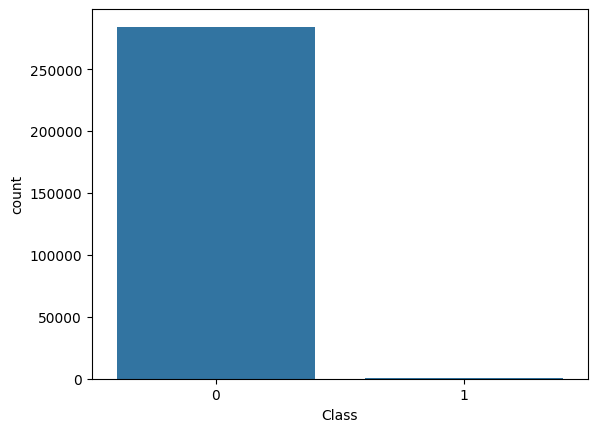

In [147]:
sns.barplot(df['Class'].value_counts())
plt.show()


In [148]:
'''fraud=df[df['Class']==1]
normal=df[df['Class']==0]

not_fraud_sampled=normal.sample(n=3000,random_state=42)
new_df=pd.concat([fraud,not_fraud_sampled],axis=0)

new_df=new_df.sample(frac=1,random_state=42).reset_index(drop=True)'''



"fraud=df[df['Class']==1]\nnormal=df[df['Class']==0]\n\nnot_fraud_sampled=normal.sample(n=3000,random_state=42)\nnew_df=pd.concat([fraud,not_fraud_sampled],axis=0)\n\nnew_df=new_df.sample(frac=1,random_state=42).reset_index(drop=True)"

In [149]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [150]:
df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [151]:
df.drop_duplicates(inplace=True)

In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
df.corr()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
V1,1.000000,0.007498,-0.002868,0.002387,-0.010153,-0.003036,-0.007147,-0.002393,-0.003042,0.002174,...,-0.001681,-0.002410,-0.004100,-0.003064,0.000160,-0.015559,-0.004250,-0.228581,-0.094504,0.118086
V2,0.007498,1.000000,0.005093,-0.002115,0.004385,0.001042,0.006435,0.003359,0.000854,0.000941,...,0.001478,-0.004121,0.001261,-0.001968,-0.000087,0.007372,0.001687,-0.533483,0.084664,-0.010506
V3,-0.002868,0.005093,1.000000,0.001742,0.001439,0.005513,-0.011653,-0.000266,-0.003591,-0.010156,...,-0.000381,0.000926,0.003702,0.002575,0.000551,-0.007597,-0.000756,-0.215083,-0.183509,-0.421951
V4,0.002387,-0.002115,0.001742,1.000000,0.004271,0.004045,0.003473,0.002293,0.003620,0.001660,...,0.000214,0.000527,0.003029,0.001266,-0.001239,0.002078,0.000163,0.099125,0.129687,-0.107069
V5,-0.010153,0.004385,0.001439,0.004271,1.000000,-0.012342,-0.008527,-0.001312,-0.000541,-0.005124,...,0.000353,0.001146,-0.004884,-0.002874,0.000124,-0.005986,-0.000421,-0.388573,-0.088124,0.173831
V6,-0.003036,0.001042,0.005513,0.004045,-0.012342,1.000000,0.004834,-0.002800,-0.002817,-0.001415,...,0.002410,-0.000646,-0.007303,-0.002479,0.000406,-0.000348,0.000962,0.220121,-0.044167,-0.062903
V7,-0.007147,0.006435,-0.011653,0.003473,-0.008527,0.004834,1.000000,-0.004837,-0.001945,-0.013934,...,-0.002215,0.003962,0.001767,0.000605,0.000068,-0.004274,0.001628,0.400594,-0.172710,0.084949
V8,-0.002393,0.003359,-0.000266,0.002293,-0.001312,-0.002800,-0.004837,1.000000,-0.000111,0.000974,...,-0.005818,0.004903,-0.002214,-0.000980,-0.001191,0.000309,-0.000153,-0.104368,0.033177,-0.037888
V9,-0.003042,0.000854,-0.003591,0.003620,-0.000541,-0.002817,-0.001945,-0.000111,1.000000,-0.008029,...,-0.000307,0.000026,-0.002785,-0.002263,0.005305,0.007795,0.005978,-0.042382,-0.094329,-0.005694
V10,0.002174,0.000941,-0.010156,0.001660,-0.005124,-0.001415,-0.013934,0.000974,-0.008029,1.000000,...,-0.001047,0.001572,0.001005,0.001658,-0.001275,0.011271,0.009386,-0.103492,-0.207520,0.029396


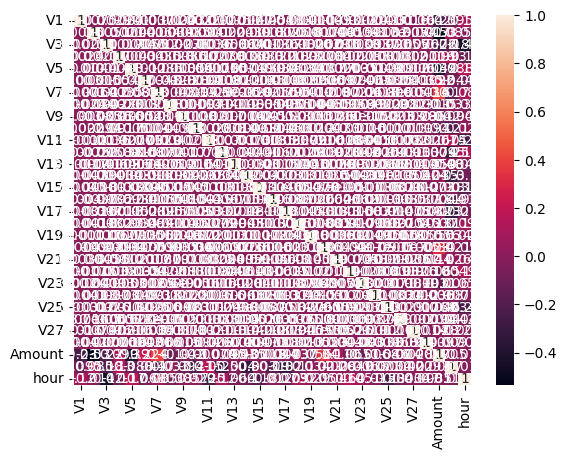

In [154]:
corr=df.corr()
sns.heatmap(corr,annot=True,)
plt.show()

In [155]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler=StandardScaler()
df[['Amount','hour']]=scaler.fit_transform(df[['Amount','hour']])
df.sample(5)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour
159070,-1.228738,-0.592477,1.828297,-2.354962,0.183962,-0.461068,-0.393473,0.347686,-0.880715,-0.025903,...,-0.375224,-0.122502,-0.539111,0.441312,-0.413965,0.225333,0.113175,-0.235406,0,0.389725
72125,1.231402,-0.713164,0.338437,-1.617229,-0.731697,0.095557,-0.719245,0.135950,1.712117,-1.016244,...,0.496856,-0.301327,-0.740008,0.606632,0.163453,0.034288,0.009270,-0.175685,0,-0.823656
171421,1.746420,-0.455969,-0.653162,1.198702,0.464170,1.764949,-0.547736,0.568589,0.962805,0.015195,...,-0.897874,0.404614,-1.716937,-0.493831,-0.996282,0.093313,-0.052101,-0.196946,0,0.541397
72881,-0.945384,0.605818,1.267199,-0.914505,0.526091,-1.479824,1.031632,-0.198629,-0.602435,-0.643205,...,-1.169136,0.160984,0.400080,-0.165910,0.494168,0.188422,0.162006,-0.187709,0,-0.823656
46967,-2.489448,-0.750923,1.786746,-1.717919,-0.782830,0.502192,-0.146699,0.224279,-0.293013,0.904845,...,1.155030,-0.122724,-0.231396,0.683797,-0.067806,0.366776,0.553903,0.278191,0,-1.127002


In [156]:
x=df.drop('Class',axis=1)
y=df['Class']

In [157]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [158]:
from IPython.lib.security import random
random_state=42
random_under_sampler=RandomUnderSampler(random_state=random_state)
x_resampled,y_resampled=random_under_sampler.fit_resample(x,y)


In [159]:
'''smote=SMOTE(random_state=42)
x_resampled,y_resampled=smote.fit_resample(x,y)'''


'smote=SMOTE(random_state=42)\nx_resampled,y_resampled=smote.fit_resample(x,y)'

In [160]:
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=42,stratify=y_resampled)

In [161]:
'''train_df=x_train.copy()
train_df['Class']=y_train'''

"train_df=x_train.copy()\ntrain_df['Class']=y_train"

In [162]:
'''fraud=train_df[train_df['Class']==1]
normal=train_df[train_df['Class']==0]

fraud_sampled=fraud.sample(n=3000,random_state=42, replace=True)


new_train_df=pd.concat([fraud,fraud_sampled],axis=0)
new_train_df=new_train_df.sample(frac=1,random_state=42)

print(new_train_df['Class'].value_counts())'''

"fraud=train_df[train_df['Class']==1]\nnormal=train_df[train_df['Class']==0]\n\nfraud_sampled=fraud.sample(n=3000,random_state=42, replace=True)\n\n\nnew_train_df=pd.concat([fraud,fraud_sampled],axis=0)\nnew_train_df=new_train_df.sample(frac=1,random_state=42)\n\nprint(new_train_df['Class'].value_counts())"

In [163]:
model_rf=RandomForestClassifier(n_estimators=50,max_depth=15,n_jobs=-1,random_state=42)
model_rf.fit(x_train,y_train)
y_proba=model_rf.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7789473684210526
[[56 39]
 [ 3 92]]
              precision    recall  f1-score   support

           0       0.95      0.59      0.73        95
           1       0.70      0.97      0.81        95

    accuracy                           0.78       190
   macro avg       0.83      0.78      0.77       190
weighted avg       0.83      0.78      0.77       190



In [164]:
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train,y_train)
y_proba=model_dt.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.2).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.9
[[83 12]
 [ 7 88]]
              precision    recall  f1-score   support

           0       0.92      0.87      0.90        95
           1       0.88      0.93      0.90        95

    accuracy                           0.90       190
   macro avg       0.90      0.90      0.90       190
weighted avg       0.90      0.90      0.90       190



In [165]:
model_svc=SVC(probability=True)
model_svc.fit(x_train,y_train)
y_proba=model_svc.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)

y_train_pred=model_svc.predict(x_train)
print(accuracy_score(y_train,y_train_pred))
print(confusion_matrix(y_train,y_train_pred))
print(classification_report(y_train,y_train_pred))

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9417989417989417
[[377   1]
 [ 43 335]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       378
           1       1.00      0.89      0.94       378

    accuracy                           0.94       756
   macro avg       0.95      0.94      0.94       756
weighted avg       0.95      0.94      0.94       756

0.8789473684210526
[[75 20]
 [ 3 92]]
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        95
           1       0.82      0.97      0.89        95

    accuracy                           0.88       190
   macro avg       0.89      0.88      0.88       190
weighted avg       0.89      0.88      0.88       190



In [166]:
model_knn=KNeighborsClassifier()
model_knn.fit(x_train,y_train)
y_proba=model_knn.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8894736842105263
[[80 15]
 [ 6 89]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88        95
           1       0.86      0.94      0.89        95

    accuracy                           0.89       190
   macro avg       0.89      0.89      0.89       190
weighted avg       0.89      0.89      0.89       190



In [167]:
model_nb=GaussianNB()
model_nb.fit(x_train,y_train)

y_proba=model_nb.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9263157894736842
[[91  4]
 [10 85]]
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        95
           1       0.96      0.89      0.92        95

    accuracy                           0.93       190
   macro avg       0.93      0.93      0.93       190
weighted avg       0.93      0.93      0.93       190



In [168]:
model_ada=AdaBoostClassifier()
model_ada.fit(x_train,y_train)
y_proba=model_ada.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.4).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

y_pred_train=model_ada.predict(x_train)
print(accuracy_score(y_train,y_pred_train))
print(classification_report(y_train,y_pred_train))
print(confusion_matrix(y_train,y_pred_train))

0.7157894736842105
[[44 51]
 [ 3 92]]
              precision    recall  f1-score   support

           0       0.94      0.46      0.62        95
           1       0.64      0.97      0.77        95

    accuracy                           0.72       190
   macro avg       0.79      0.72      0.70       190
weighted avg       0.79      0.72      0.70       190

0.9867724867724867
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       378
           1       1.00      0.98      0.99       378

    accuracy                           0.99       756
   macro avg       0.99      0.99      0.99       756
weighted avg       0.99      0.99      0.99       756

[[377   1]
 [  9 369]]


In [169]:
model_gb=GradientBoostingClassifier()
model_gb.fit(x_train,y_train)
y_proba=model_gb.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.2).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9157894736842105
[[87  8]
 [ 8 87]]
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        95
           1       0.92      0.92      0.92        95

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190



In [170]:
model_bag=BaggingClassifier(estimator=AdaBoostClassifier(),n_estimators=10,random_state=42)
model_bag.fit(x_train,y_train)
y_proba=model_bag.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.2).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:610: RuntimeWarning: divide by zero encountered in log
  np.log(sample_weight)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight

0.5
[[ 0 95]
 [ 0 95]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        95
           1       0.50      1.00      0.67        95

    accuracy                           0.50       190
   macro avg       0.25      0.50      0.33       190
weighted avg       0.25      0.50      0.33       190



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [171]:
model_vot=VotingClassifier(estimators=[('ada', AdaBoostClassifier()), ('gb', GradientBoostingClassifier()), ('rf', RandomForestClassifier())], voting='soft')
model_vot.fit(x_train,y_train)
y_proba=model_vot.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.2).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8105263157894737
[[64 31]
 [ 5 90]]
              precision    recall  f1-score   support

           0       0.93      0.67      0.78        95
           1       0.74      0.95      0.83        95

    accuracy                           0.81       190
   macro avg       0.84      0.81      0.81       190
weighted avg       0.84      0.81      0.81       190



In [172]:
from xgboost import XGBClassifier

In [173]:
model_xgb=XGBClassifier()
model_xgb.fit(x_train,y_train)
y_proba=model_xgb.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9210526315789473
[[87  8]
 [ 7 88]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        95
           1       0.92      0.93      0.92        95

    accuracy                           0.92       190
   macro avg       0.92      0.92      0.92       190
weighted avg       0.92      0.92      0.92       190



**FINAL MODEL**

In [177]:
model_svc=SVC(probability=True)
model_svc.fit(x_train,y_train)
y_proba=model_svc.predict_proba(x_test)
y_pred=(y_proba[:, 1] > 0.1).astype(int)

y_train_pred=model_svc.predict(x_train)
print(accuracy_score(y_train,y_train_pred))
print(confusion_matrix(y_train,y_train_pred))
print(classification_report(y_train,y_train_pred))

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9417989417989417
[[377   1]
 [ 43 335]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.94       378
           1       1.00      0.89      0.94       378

    accuracy                           0.94       756
   macro avg       0.95      0.94      0.94       756
weighted avg       0.95      0.94      0.94       756

0.8789473684210526
[[75 20]
 [ 3 92]]
              precision    recall  f1-score   support

           0       0.96      0.79      0.87        95
           1       0.82      0.97      0.89        95

    accuracy                           0.88       190
   macro avg       0.89      0.88      0.88       190
weighted avg       0.89      0.88      0.88       190



In [174]:
import ipywidgets as widgets
from IPython.display import display

In [175]:
input_widgets = {}
for col in x.columns:
    input_widgets[col] = widgets.FloatText(
        value=0.0, # Default value
        description=f'{col}:',
        disabled=False
    )
display(widgets.VBox(list(input_widgets.values())))

In [176]:
prediction_button = widgets.Button(description="Predict Fraud")
prediction_output = widgets.Output()

def on_button_click(b):
    with prediction_output:
        prediction_output.clear_output()
        # Collect input values
        input_values = {col: input_widgets[col].value for col in x.columns}

        # Create a DataFrame from the input values
        input_df = pd.DataFrame([input_values])

        # Preprocess 'Amount' and 'hour' using the already fitted scaler
        # The scaler is named 'scaler' and was fit on df[['Amount', 'hour']]
        # We need to apply the transformation to the specific columns from the input_df
        input_df[['Amount', 'hour']] = scaler.transform(input_df[['Amount', 'hour']])

        # Make prediction using model_xgb
        prediction_proba = model_svc.predict_proba(input_df)
        # Using the same threshold as when the model was evaluated
        predicted_class = (prediction_proba[:, 1] > 0.1).astype(int)[0]

        if predicted_class == 1:
            print("Prediction: Fraudulent Transaction (Class 1)")
        else:
            print("Prediction: Not Fraudulent Transaction (Class 0)")

prediction_button.on_click(on_button_click)

display(prediction_button, prediction_output)

Button(description='Predict Fraud', style=ButtonStyle())

Output()